In [1]:
import numpy as np
import statistics
import seaborn as sns
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits

In [52]:
df=pd.read_csv('Listings.csv',encoding="latin1")
features = [
    "price",
    "accommodates",
    "bedrooms",
    "minimum_nights",
    "maximum_nights",
    "host_total_listings_count",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "latitude",
    "longitude"
]


print(df[features].describe())

/var/folders/rd/pqn4crp95cbb0zy1xkn347jh0000gn/T/ipykernel_51216/3069369883.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Listings.csv',encoding="latin1")


               price   accommodates       bedrooms  minimum_nights  \
count  279712.000000  279712.000000  250277.000000   279712.000000   
mean      608.792737       3.288736       1.515509        8.050967   
std      3441.826611       2.133379       1.153080       31.518946   
min         0.000000       0.000000       1.000000        1.000000   
25%        75.000000       2.000000       1.000000        1.000000   
50%       150.000000       2.000000       1.000000        2.000000   
75%       474.000000       4.000000       2.000000        5.000000   
max    625216.000000      16.000000      50.000000     9999.000000   

       maximum_nights  host_total_listings_count  review_scores_rating  \
count    2.797120e+05              279547.000000         188307.000000   
mean     2.755860e+04                  24.581612             93.405195   
std      7.282875e+06                 284.041143             10.070437   
min      1.000000e+00                   0.000000             20.000000   

In [53]:

X=df[features].dropna()
X=X[X['price']> 1000]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


In [69]:
def plot_correlation_circle(initial_variables, new_variables, feature_names,c1=0,c2=1, pc_labels=['PC1', 'PC2']):
    plt.figure(figsize=(8, 8))
    
    # Tracer un cercle unité
    circle = plt.Circle((0, 0), 1, color='gray', fill=False)
    plt.gca().add_artist(circle)
    
    # Tracer les flèches (correlations des variables)
    for i in range(len(feature_names)):
        x=np.corrcoef(new_variables[:,c1],initial_variables[:,i])[0,1]
        y=np.corrcoef(new_variables[:,c2],initial_variables[:,i])[0,1]
        plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.001, fc='red', ec='red')
        plt.text(x * 1.1, y * 1.1, feature_names[i], color='black', ha='center', va='center')
    
    # Ajustements esthétiques
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.xlabel(pc_labels[0])
    plt.ylabel(pc_labels[1])
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.title('Cercle de corrélation')
    plt.show()

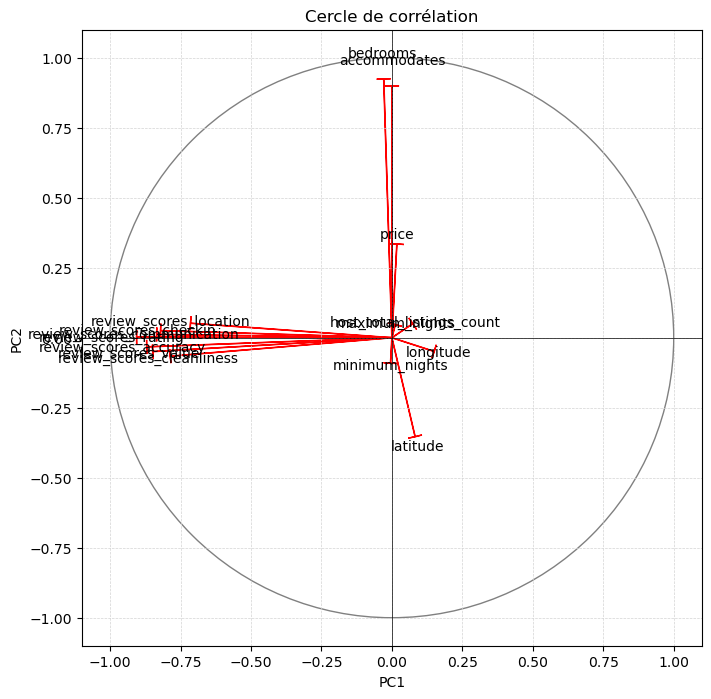

In [70]:
pca=PCA() #n_components=2)
X_pca=pca.fit_transform(X_scaled)

plot_correlation_circle(X_scaled,X_pca,features)


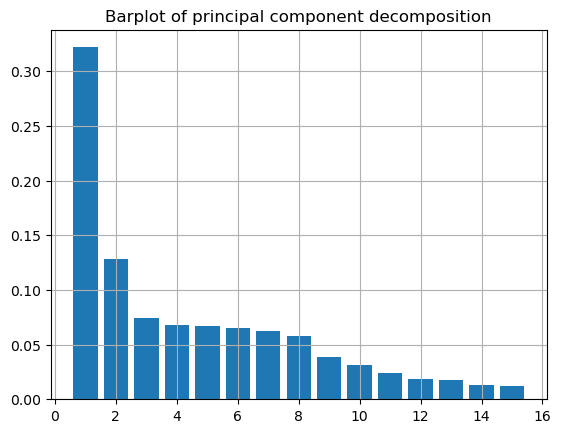

In [63]:

i=np.arange(1,pca.n_components_+1)
plt.bar(i,pca.explained_variance_ratio_)
plt.title('Barplot of principal component decomposition')
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

price = X['prices']
sims = []
for comp in pca.components_:
    sims.append(cosine_similarity(price, comp))

print()

In [64]:
feature_names = features
price_idx = feature_names.index("price")

# -------------------------
# 5. Extract loadings
# -------------------------
loadings = []

for i, comp in enumerate(pca.components_):
    loading = comp[price_idx]
    loadings.append((i, loading))

# -------------------------
# 6. Sort by importance
# -------------------------
sorted_loadings = sorted(loadings, key=lambda x: abs(x[1]), reverse=True)

# -------------------------
# 7. Print results
# -------------------------
print("Components most related to PRICE:\n")

for i, val in sorted_loadings:
    print(f"Component {i+1}: loading = {val:.4f}")

Components most related to PRICE:

Component 7: loading = 0.8407
Component 8: loading = 0.3431
Component 2: loading = 0.2409
Component 3: loading = 0.1934
Component 6: loading = 0.1762
Component 4: loading = 0.1708
Component 5: loading = -0.1386
Component 11: loading = -0.0175
Component 14: loading = -0.0121
Component 15: loading = -0.0086
Component 1: loading = 0.0080
Component 10: loading = 0.0040
Component 9: loading = 0.0029
Component 12: loading = -0.0026
Component 13: loading = -0.0002
